In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline

In [2]:
df = pd.read_excel('../../../data/20260124.katsumi_B56G5.xlsm', sheet_name='瞬き除去')
df

,経過時間,経過時間.1,経過時間.2,カテゴリ,カテゴリ.1,瞳孔面積,瞬き除去,Unnamed: 7
0,[hh:mm:ss:fff],[ms],[s],短波長光,長波長光,[dot],[dot],NaN
1,00:00:00:073,73,0.073,0,0,4827,4827,NaN
2,00:00:00:106,106,0.106,0,0,4872,4872,NaN
3,00:00:00:139,139,0.139,0,0,4964,4964,NaN
4,00:00:00:173,173,0.173,0,0,4841,4841,NaN
...,...,...,...,...,...,...,...,...
1091,00:00:36:411,36411,36.411,0,0,NaN,NaN,NaN
1092,00:00:36:444,36444,36.444,0,0,NaN,NaN,NaN
1093,00:00:36:477,36477,36.477,0,0,NaN,NaN,NaN
1094,00:00:36:511,36511,36.511,0,0,NaN,NaN,NaN


In [3]:
df = df[1:-7]
en_df = df.rename(columns={
    '経過時間': 'timestamp', 
    '経過時間.1': 'elasped_ms',
    '経過時間.2': 'elasped_sec',
    'カテゴリ': 'blue_active',
    'カテゴリ.1': 'green_active',
    '瞳孔面積': 'raw_pupil_area_px',
    '瞬き除去': 'cleaned_pupil_area_px',
})

en_df

,timestamp,elasped_ms,elasped_sec,blue_active,green_active,raw_pupil_area_px,cleaned_pupil_area_px,Unnamed: 7
1,00:00:00:073,73,0.073,0,0,4827,4827,NaN
2,00:00:00:106,106,0.106,0,0,4872,4872,NaN
3,00:00:00:139,139,0.139,0,0,4964,4964,NaN
4,00:00:00:173,173,0.173,0,0,4841,4841,NaN
5,00:00:00:206,206,0.206,0,0,4889,4889,NaN
...,...,...,...,...,...,...,...,...
1084,00:00:36:177,36177,36.177,0,0,4711,4711,NaN
1085,00:00:36:211,36211,36.211,0,0,4590,4590,NaN
1086,00:00:36:244,36244,36.244,0,0,4715,4715,NaN
1087,00:00:36:277,36277,36.277,0,0,4651,4651,NaN


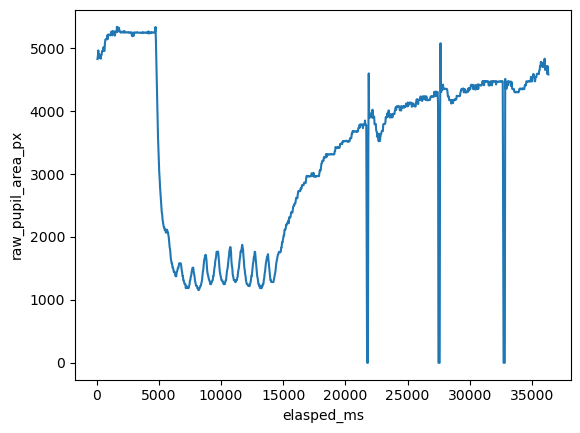

In [4]:
sns.lineplot(en_df, x='elasped_ms', y='raw_pupil_area_px')
plt.show()

In [5]:
time_col = 'elasped_ms'
y_col = 'raw_pupil_area_px'

valid_mask = en_df['raw_pupil_area_px'].notna() & en_df[time_col].notna()
x_valid = en_df.loc[valid_mask, time_col]
y_valid = en_df.loc[valid_mask, 'raw_pupil_area_px']
en_df

,timestamp,elasped_ms,elasped_sec,blue_active,green_active,raw_pupil_area_px,cleaned_pupil_area_px,Unnamed: 7
1,00:00:00:073,73,0.073,0,0,4827,4827,NaN
2,00:00:00:106,106,0.106,0,0,4872,4872,NaN
3,00:00:00:139,139,0.139,0,0,4964,4964,NaN
4,00:00:00:173,173,0.173,0,0,4841,4841,NaN
5,00:00:00:206,206,0.206,0,0,4889,4889,NaN
...,...,...,...,...,...,...,...,...
1084,00:00:36:177,36177,36.177,0,0,4711,4711,NaN
1085,00:00:36:211,36211,36.211,0,0,4590,4590,NaN
1086,00:00:36:244,36244,36.244,0,0,4715,4715,NaN
1087,00:00:36:277,36277,36.277,0,0,4651,4651,NaN


In [6]:
en_df[en_df['raw_pupil_area_px'] == 0]

,timestamp,elasped_ms,elasped_sec,blue_active,green_active,raw_pupil_area_px,cleaned_pupil_area_px,Unnamed: 7
651,00:00:21:742,21742,21.742,0,0,0,3805,NaN
652,00:00:21:775,21775,21.775,0,0,0,3820,3835
653,00:00:21:808,21808,21.808,0,0,0,3850,NaN
823,00:00:27:476,27476,27.476,0,0,0,4305.25,NaN
824,00:00:27:509,27509,27.509,0,0,0,4306.375,NaN
825,00:00:27:543,27543,27.543,0,0,0,4307.5,NaN
826,00:00:27:576,27576,27.576,0,0,0,4308.625,NaN
980,00:00:32:710,32710,32.71,0,0,0,4446.75,NaN
981,00:00:32:743,32743,32.743,0,0,0,4433.125,4419.5
982,00:00:32:777,32777,32.777,0,0,0,4405.875,NaN


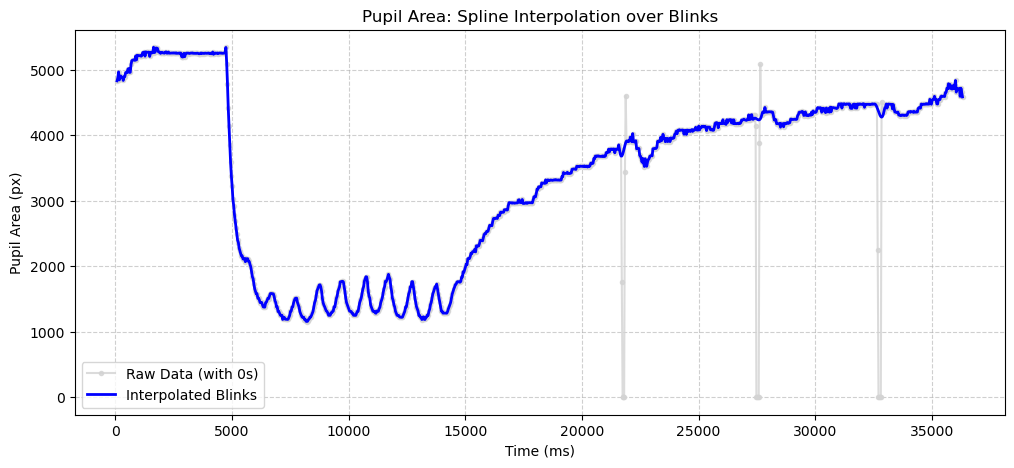

In [ ]:
# 1. Create a copy of the raw data to be cleaned
en_df['cleaned_pupil_area_px'] = en_df[y_col].astype(float)
# 2. Identify the blink spikes (where the tracker lost the pupil, i.e., area is 0)
# Note: You can also use `< 100` if the tracker sometimes outputs tiny numbers during blinks
blink_mask = en_df['cleaned_pupil_area_px'] == 0
# --- BEST PRACTICE FOR PUPILLOMETRY ---
# The eyelid partially covers the pupil just before and after the 0, creating bad data.
# We use a "rolling window" to expand the blink mask slightly (e.g., 3 rows before and after)
# to ensure we interpolate over the entire blink artifact, not just the 0s.
expanded_blink_mask = blink_mask.rolling(window=7, center=True, min_periods=1).max().astype(bool)
# 3. Erase the blink data by setting it to NaN
en_df.loc[expanded_blink_mask, 'cleaned_pupil_area_px'] = np.nan
# 4. Bridge the gaps using Cubic Spline Interpolation
# This draws a smooth mathematical curve across the NaN gaps using the surrounding valid data.
en_df['cleaned_pupil_area_px'] = en_df['cleaned_pupil_area_px'].interpolate(method='cubic')
# --- Plotting to verify the interpolation ---
plt.figure(figsize=(12, 5))
# Plot raw data (showing the drops to 0)
plt.plot(en_df[time_col], en_df[y_col], label='Raw Data (with 0s)', color='lightgray', marker='.', alpha=0.8)
# Plot cleaned data (showing the smooth bridge)
plt.plot(en_df[time_col], en_df['cleaned_pupil_area_px'], label='Interpolated Blinks', color='blue', linewidth=2)
plt.title('Pupil Area: Spline Interpolation over Blinks')
plt.xlabel('Time (ms)')
plt.ylabel('Pupil Area (px)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

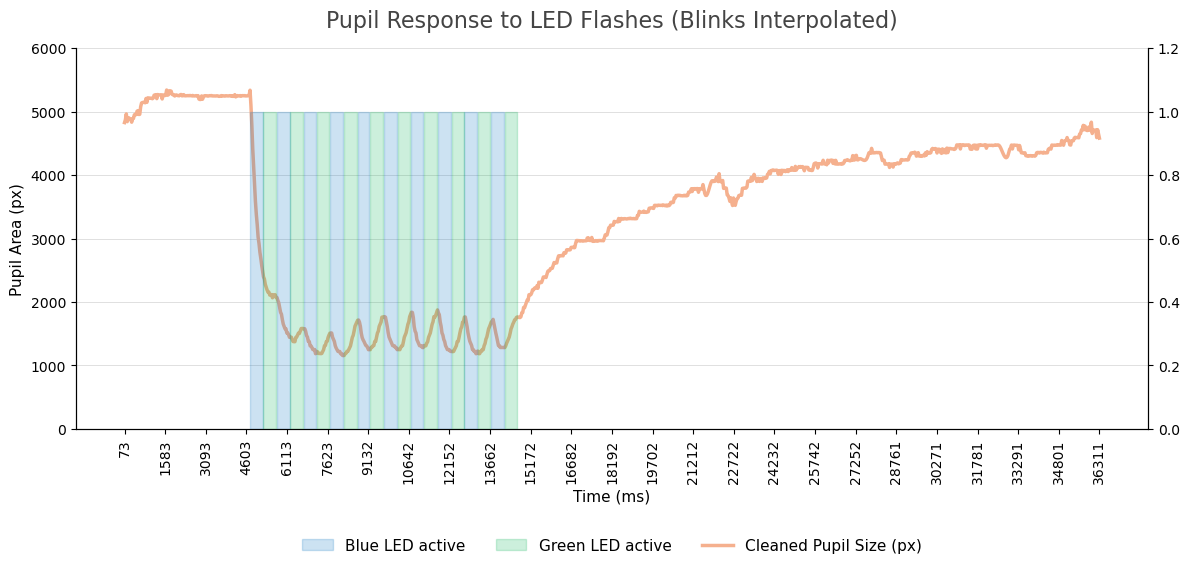

In [11]:
time_col = 'elasped_ms'
raw_y_col = 'raw_pupil_area_px'
cleaned_y_col = 'cleaned_pupil_area_px'
blue_col = 'blue_active'
green_col = 'green_active'

# --- 2. DATA CLEANING (Cubic Spline Interpolation over Blinks) ---
en_df[cleaned_y_col] = en_df[raw_y_col].astype(float)
blink_mask = en_df[cleaned_y_col] == 0

# Expand the blink mask by 3 rows on each side (~100ms) to catch the eyelid closing/opening
expanded_blink_mask = blink_mask.rolling(window=7, center=True, min_periods=1).max().astype(bool)

# Erase the blink data (set to NaN) and bridge the gaps using cubic interpolation
en_df.loc[expanded_blink_mask, cleaned_y_col] = np.nan
en_df[cleaned_y_col] = en_df[cleaned_y_col].interpolate(method='cubic')


# --- 3. PREPARE DATA FOR PLOTTING ---
x = en_df[time_col].astype(float)
y_clean = en_df[cleaned_y_col].astype(float)
blue_led = en_df[blue_col].astype(float)
green_led = en_df[green_col].astype(float)


# --- 4. PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis (Left): Cleaned Pupil Area
ax1.plot(x, y_clean, color='#f5b08e', linewidth=2.5, label='Cleaned Pupil Size (px)')
ax1.set_ylim(0, 6000)
ax1.set_yticks([0, 1000, 2000, 3000, 4000, 5000, 6000])

# Configure X-axis ticks
ax1.set_xticks(np.linspace(x.min(), x.max(), 25))
ax1.tick_params(axis='x', rotation=90)
ax1.set_xlabel('Time (ms)', fontsize=11)
ax1.set_ylabel('Pupil Area (px)', fontsize=11)
ax1.spines['top'].set_visible(False)

# Secondary Axis (Right): LED Stimulus Background Bars
ax2 = ax1.twinx()
ax2.set_ylim(0, 1.2)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
ax2.spines['top'].set_visible(False)

# Draw the Blue and Green blocks
ax2.fill_between(x, 0, blue_led, where=(blue_led > 0), 
                 color='#0070C0', alpha=0.2, step='mid', label='Blue LED active')
ax2.fill_between(x, 0, green_led, where=(green_led > 0), 
                 color='#00B050', alpha=0.2, step='mid', label='Green LED active')

# Formatting & Legends
plt.title('Pupil Response to LED Flashes (Blinks Interpolated)', fontsize=16, pad=15, color='#444444')

# Combine legends from both axes and place at the bottom
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_2 + lines_1, labels_2 + labels_1, 
           loc='upper center', bbox_to_anchor=(0.5, -0.25), 
           ncol=3, frameon=False, fontsize=11)

# Add horizontal grid lines for readability
ax1.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()